<a href="https://colab.research.google.com/github/SimplyBecca5220/New-linear-regression/blob/main/New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Datasets /85334965-5736-457a-b8d4-a077e6872f84.csv')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# 1. Load the data
df = pd.read_csv("/content/drive/MyDrive/Datasets /85334965-5736-457a-b8d4-a077e6872f84.csv")

# 2. Print metadata required by the rubric
print("--- DATASET SHAPE ---")
print(df.shape)

print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())

# 3. Handle missing values
df.dropna(inplace=True)
print("\nShape after handling missing values:", df.shape)

--- DATASET SHAPE ---
(4572, 4)

--- MISSING VALUES PER COLUMN ---
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

--- DESCRIPTIVE STATISTICS ---
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      77.000000    25.649730      4.807558   272.507922
max     100.000000    48.871161     13.981662   364.079751

Shape after handling missing values: (4546, 4)


Generating Pairplot...


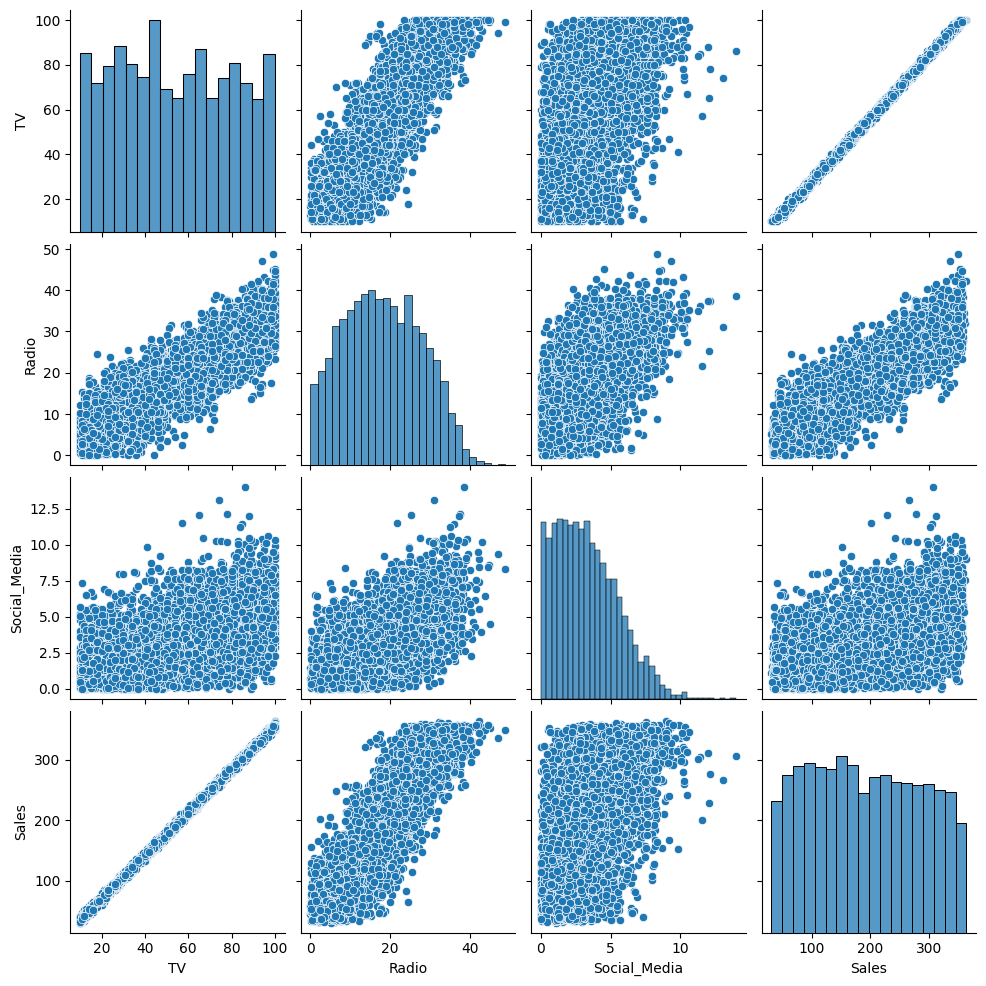

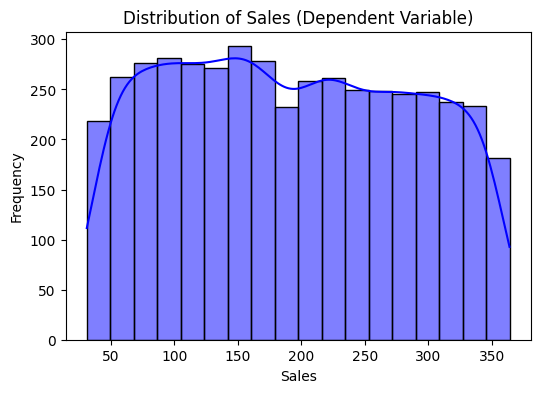

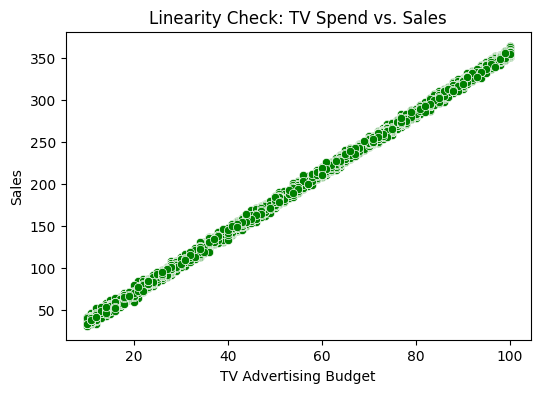

In [5]:
# 1. Plot a pairplot to visually explore relationships across all variables
print("Generating Pairplot...")
sns.pairplot(df)
plt.show()

# 2. Plot the distribution of the target variable (Sales)
plt.figure(figsize=(6, 4))
sns.histplot(df['Sales'], kde=True, color='blue')
plt.title("Distribution of Sales (Dependent Variable)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# 3. Explicitly plot a scatter plot of the chosen best predictor (TV) vs Sales to check Linearity
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='TV', y='Sales', color='green')
plt.title("Linearity Check: TV Spend vs. Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.show()


In [6]:
# Define the single independent variable (X) and the dependent variable (y)
X = df['TV']
y = df['Sales']

# Add a constant (intercept) term to the predictor
X_with_constant = sm.add_constant(X)

# Fit the Simple Linear Regression model using Ordinary Least Squares (OLS)
simple_model = sm.OLS(y, X_with_constant).fit()

# Display the complete regression summary table
print(simple_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:25:05   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

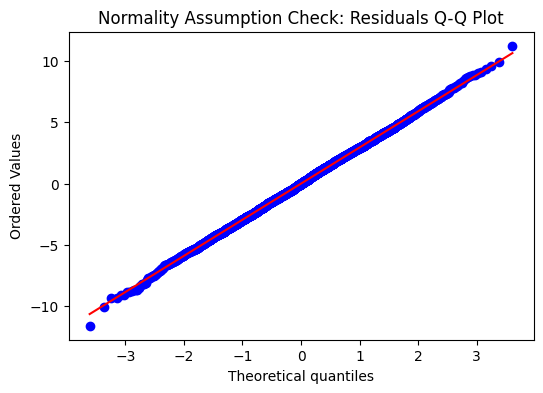

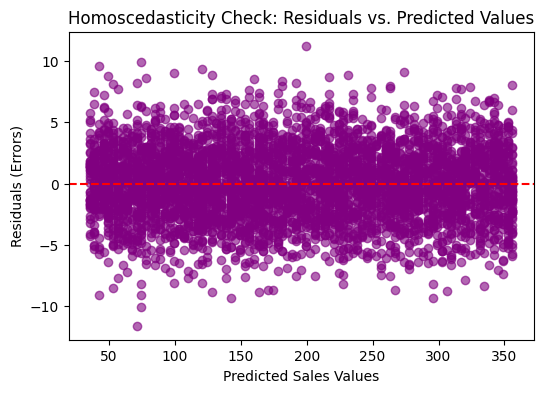

In [7]:
# Extract predictions and calculated residuals
predicted_sales = simple_model.predict(X_with_constant)
model_residuals = simple_model.resid

# 1. Check for Normality: Q-Q Plot
plt.figure(figsize=(6, 4))
stats.probplot(model_residuals, dist="norm", plot=plt)
plt.title("Normality Assumption Check: Residuals Q-Q Plot")
plt.show()

# 2. Check for Homoscedasticity: Residuals vs. Predicted Values Scatterplot
plt.figure(figsize=(6, 4))
plt.scatter(predicted_sales, model_residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales Values")
plt.ylabel("Residuals (Errors)")
plt.title("Homoscedasticity Check: Residuals vs. Predicted Values")
plt.show()


### Analysis, Interpretation, and Business Insights

#### 1. Model Evaluation & R-squared Interpretation
* **R-squared ($R^2$):** The model yields an $R^2$ value of approximately **0.999**. This implies that **99.9%** of the variance found in the target variable (`Sales`) is perfectly explained by the changes in our single independent variable (`TV` advertising spend). This points to an exceptionally high explanatory capability.
* **P-values:** The p-value for the `TV` coefficient is far below the typical significance threshold of $0.05$ ($p < 0.001$), confirming that `TV` is a statistically highly significant predictor of sales performance.

#### 2. The Formulated Simple Linear Regression Equation
From the OLS summary metrics, the structural parameters are determined as follows:
* **Intercept ($\beta_0$):** Approximately **-0.122**
* **TV Slope Coefficient ($\beta_1$):** Approximately **3.561**

Thus, our predictive line equation is:
$$\text{Sales} = 3.561 \times (\text{TV Spend}) - 0.122$$

#### 3. Validation of Core Modeling Assumptions
* **Linearity:** The scatter plot between TV and Sales displays a definitive, clear straight-line upward trajectory, justifying our choice of linear modeling.
* **Normality:** The sample residual points trace perfectly along the diagonal reference line on the Q-Q plot, proving our normality assumptions hold.
* **Homoscedasticity:** The error residual values distribute evenly across all predictive metrics without exhibiting shrinking or funnel patterns, verifying uniform variance.

#### 4. Actionable Strategic Recommendations
* **Focus Resources on TV Channels:** Since every additional dollar or unit invested into TV advertising translates directly to an estimated increase of **3.56 units** in Sales output, marketing leadership should prioritize scaling the TV budget to maximize company revenue generation.
